In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [ ]:
import os

# Folder to store all figures
FIGURE_FOLDER = "/content/Experiment2_Figures"

# Create the folder if it doesn't exist
os.makedirs(FIGURE_FOLDER, exist_ok=True)

print(f"Figures will be saved in: {FIGURE_FOLDER}")

Figures will be saved in: /content/Experiment2_Figures


In [ ]:
def save_plot(filename):
    """
    Save the current matplotlib figure as EPS with 600 DPI.
    """
    filepath = os.path.join(FIGURE_FOLDER, filename + ".eps")
    plt.savefig(filepath,
                format="eps",
                dpi=600,
                bbox_inches="tight")
    print(f"Saved: {filepath}")

In [ ]:
# Load the Fashion-MNIST dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
print("Training Images Shape :", X_train.shape)
print("Training Labels Shape :", y_train.shape)

print("Testing Images Shape  :", X_test.shape)
print("Testing Labels Shape  :", y_test.shape)

Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)


Saved: /content/Experiment2_Figures/Sample_Images.eps


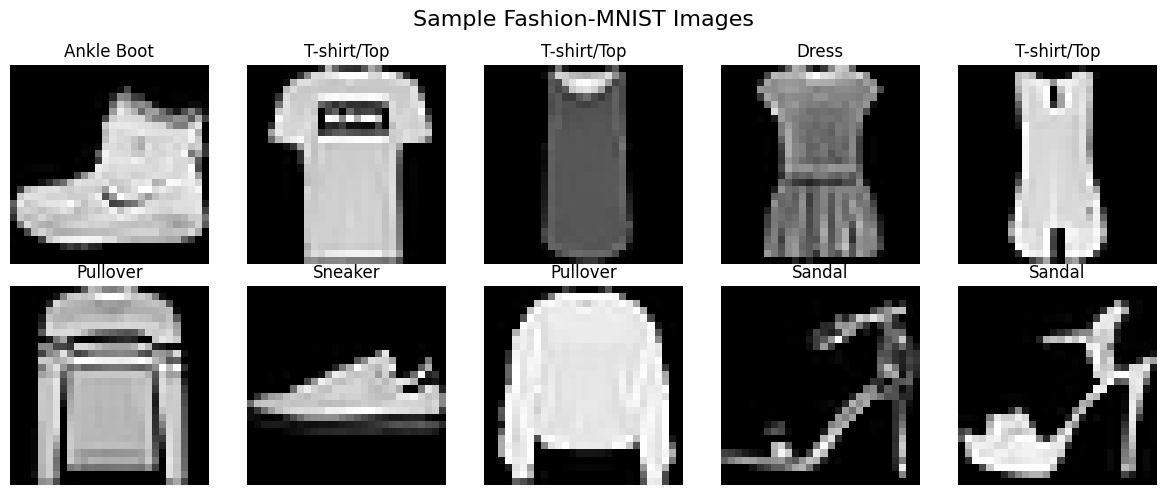

In [ ]:
# Fashion-MNIST class names
class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.suptitle("Sample Fashion-MNIST Images", fontsize=16)
plt.tight_layout()
save_plot("Sample_Images")
plt.show()

Saved: /content/Experiment2_Figures/Class_Distribution.eps


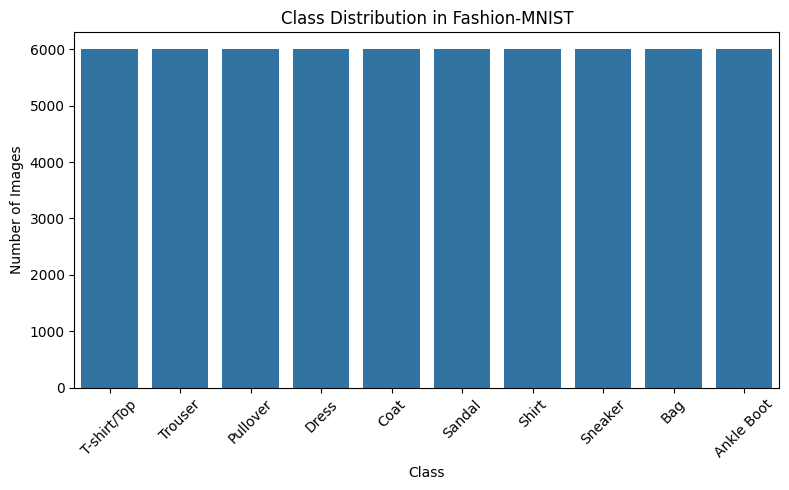

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x=y_train)

plt.xticks(range(10), class_names, rotation=45)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution in Fashion-MNIST")

plt.tight_layout()

save_plot("Class_Distribution")
plt.show()

In [ ]:
print("Before Preprocessing")
print("-" * 40)

print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Before Preprocessing
----------------------------------------
Training Images : (60000, 28, 28)
Testing Images  : (10000, 28, 28)
Training Labels : (60000,)
Testing Labels  : (10000,)


In [ ]:
# Flatten the images
X_train_flat = X_train.reshape(X_train.shape[0], 28 * 28)
X_test_flat = X_test.reshape(X_test.shape[0], 28 * 28)

In [ ]:
# Normalize pixel values
X_train_flat = X_train_flat.astype("float32") / 255.0
X_test_flat = X_test_flat.astype("float32") / 255.0

In [ ]:
# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

In [ ]:
print("\nAfter Preprocessing")
print("-" * 40)

print("Training Images :", X_train_flat.shape)
print("Testing Images  :", X_test_flat.shape)

print("Training Labels :", y_train_cat.shape)
print("Testing Labels  :", y_test_cat.shape)


After Preprocessing
----------------------------------------
Training Images : (60000, 784)
Testing Images  : (10000, 784)
Training Labels : (60000, 10)
Testing Labels  : (10000, 10)


In [ ]:
print("First Flattened Image Shape :", X_train_flat[0].shape)

print("\nFirst 20 Pixel Values")

print(X_train_flat[0][:20])

First Flattened Image Shape : (784,)

First 20 Pixel Values
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
print("Original Label :", y_train[0])

print("One-Hot Encoded Label :")

print(y_train_cat[0])

Original Label : 9
One-Hot Encoded Label :
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [ ]:
# Create the MLP model
model = Sequential([

    # Input Layer + Hidden Layer 1
    Dense(128, activation='relu', input_shape=(784,)),

    # Hidden Layer 2
    Dense(64, activation='relu'),

    # Output Layer
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train the model
history = model.fit(
    X_train_flat,
    y_train_cat,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8174 - loss: 0.5091 - val_accuracy: 0.8518 - val_loss: 0.4124
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8629 - loss: 0.3761 - val_accuracy: 0.8673 - val_loss: 0.3744
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8764 - loss: 0.3367 - val_accuracy: 0.8730 - val_loss: 0.3520
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8848 - loss: 0.3133 - val_accuracy: 0.8817 - val_loss: 0.3347
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8892 - loss: 0.2963 - val_accuracy: 0.8788 - val_loss: 0.3286
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8972 - loss: 0.2772 - val_accuracy: 0.8804 - val_loss: 0.3354
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9010 - loss: 0.2675 - val_accuracy: 0.8817 - val_loss: 0.3235
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9044 - loss: 0.2585 -

In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [ ]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(X_test_flat, y_test_cat, verbose=0)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

Test Loss     : 0.4279
Test Accuracy : 0.8798


In [ ]:
# Predict class probabilities
y_pred_prob = model.predict(X_test_flat)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

# True labels
y_true = y_test

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 0.8798
Precision: 0.8800
Recall   : 0.8798
F1-Score : 0.8783


In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

 T-shirt/Top       0.83      0.84      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.77      0.85      0.81      1000
       Dress       0.83      0.94      0.88      1000
        Coat       0.82      0.77      0.79      1000
      Sandal       0.99      0.93      0.96      1000
       Shirt       0.75      0.62      0.68      1000
     Sneaker       0.89      0.98      0.94      1000
         Bag       0.97      0.97      0.97      1000
  Ankle Boot       0.96      0.93      0.94      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



Saved: /content/Experiment2_Figures/Confusion_Matrix.eps


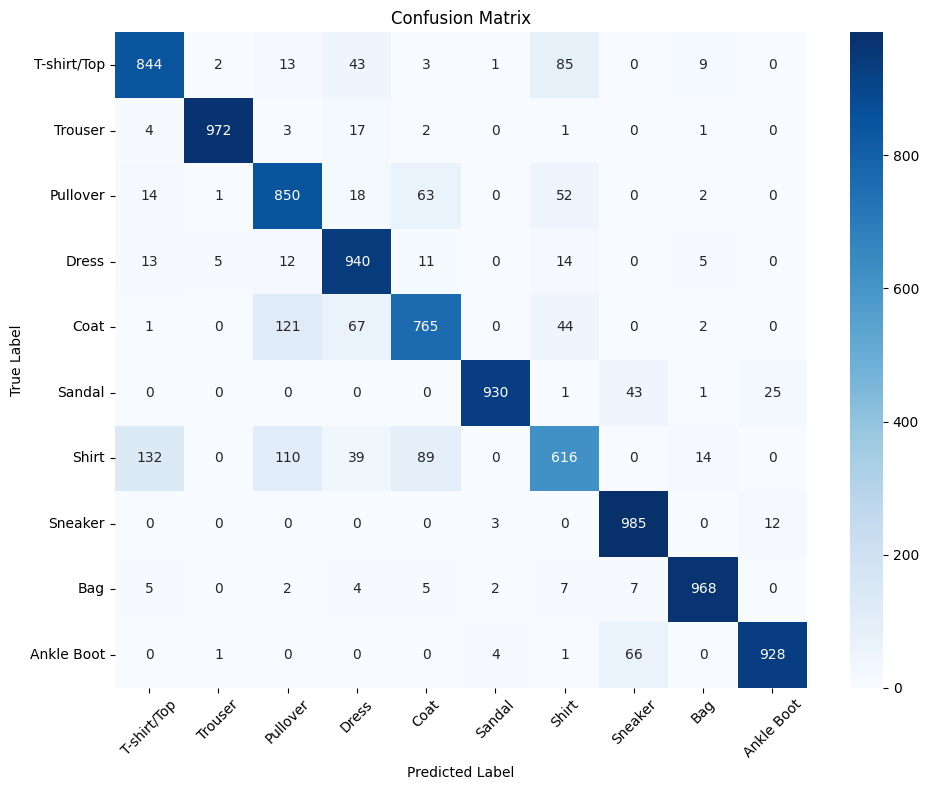

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
save_plot("Confusion_Matrix")
plt.show()

Saved: /content/Experiment2_Figures/Accuracy_vs_Epoch.eps


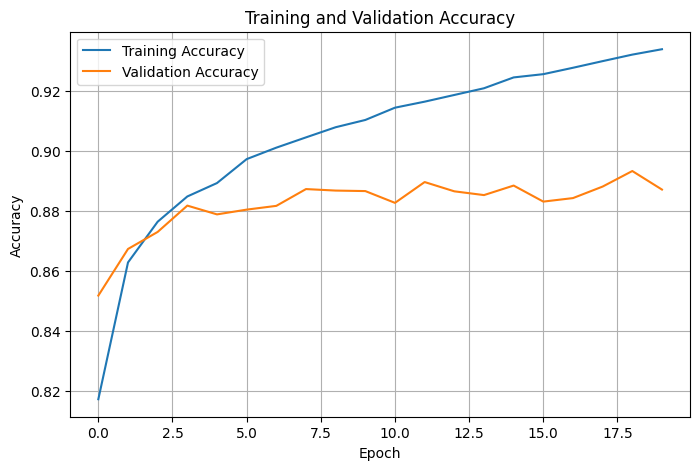

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True)
save_plot("Accuracy_vs_Epoch")

plt.show()

Saved: /content/Experiment2_Figures/Loss_vs_Epoch.eps


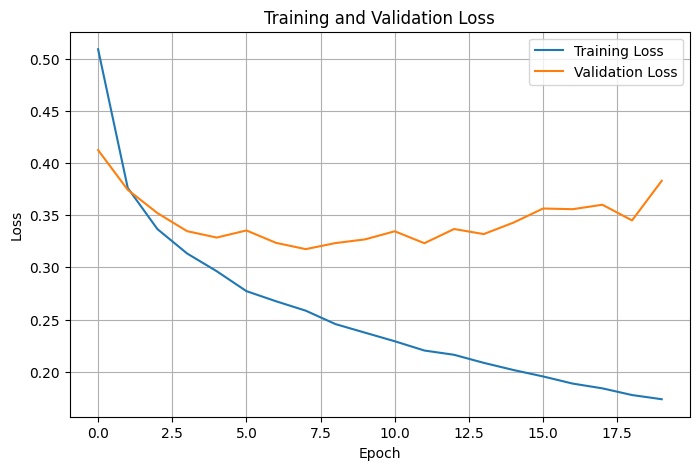

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)
save_plot("Loss_vs_Epoch")

plt.show()

In [ ]:
!pip install scikeras -q
!pip install -U scikeras
!pip install -U scikit-learn

In [ ]:
from scikeras.wrappers import KerasClassifier

from sklearn.model_selection import RandomizedSearchCV

In [ ]:
def create_model(
    neurons1=128,
    neurons2=64,
    optimizer='adam',
    activation='relu'
):

    model = Sequential([
        Dense(neurons1, activation=activation, input_shape=(784,)),
        Dense(neurons2, activation=activation),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
keras_model = KerasClassifier(
    model=create_model,
    verbose=0
)

In [ ]:
param_grid = {

    "model__neurons1": [64, 128, 256],

    "model__neurons2": [32, 64, 128],

    "model__activation": ["relu", "tanh"],

    "optimizer": ["adam", "rmsprop"],

    "batch_size": [32, 64],

    "epochs": [10, 20]
}

In [ ]:
random_search = RandomizedSearchCV(

    estimator=keras_model,

    param_distributions=param_grid,

    n_iter=5,

    cv=3,

    scoring="accuracy",

    random_state=42,

    n_jobs=-1
)

In [ ]:
random_search.fit(
    X_train_flat,
    y_train_cat
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KerasClassifi..._weight=None )
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'batch_size': [32, 64], 'epochs': [10, 20], 'model__activation': ['relu', 'tanh'], 'model__neurons1': [64, 128, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multip

In [ ]:
print("Best Parameters:\n")

print(random_search.best_params_)

print("\nBest Cross-Validation Accuracy:")

print(random_search.best_score_)

Best Parameters:

{'optimizer': 'rmsprop', 'model__neurons2': 64, 'model__neurons1': 128, 'model__activation': 'relu', 'epochs': 20, 'batch_size': 64}

Best Cross-Validation Accuracy:
0.8878833333333334


In [ ]:
print("Baseline Accuracy :", accuracy)
print("Optimized Accuracy:", test_accuracy)

Baseline Accuracy : 0.8798
Optimized Accuracy: 0.8903


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predictions from optimized model
y_pred_opt = best_model.predict(X_test_flat)

# If predictions are probabilities or one-hot vectors, convert to class labels
if len(y_pred_opt.shape) > 1:
    y_pred_opt = np.argmax(y_pred_opt, axis=1)

# If y_test is one-hot encoded, convert it to class labels
if len(y_test.shape) > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

# Compute metrics
accuracy_opt = accuracy_score(y_true, y_pred_opt)
precision_opt = precision_score(y_true, y_pred_opt, average='weighted')
recall_opt = recall_score(y_true, y_pred_opt, average='weighted')
f1_opt = f1_score(y_true, y_pred_opt, average='weighted')

print(f"Optimized Accuracy : {accuracy_opt:.4f}")
print(f"Optimized Precision: {precision_opt:.4f}")
print(f"Optimized Recall   : {recall_opt:.4f}")
print(f"Optimized F1-Score : {f1_opt:.4f}")

Optimized Accuracy : 0.8903
Optimized Precision: 0.8911
Optimized Recall   : 0.8903
Optimized F1-Score : 0.8904


In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Baseline MLP", "Optimized MLP"],
    "Accuracy": [accuracy, test_accuracy]
})

comparison_df

,Model,Accuracy
0,Baseline MLP,0.8798
1,Optimized MLP,0.8903


Saved: /content/Experiment2_Figures/Baseline_vs_Optimized_Accuracy.eps


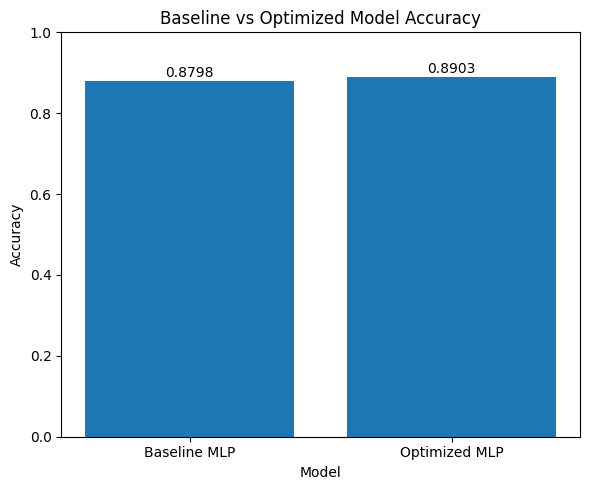

In [ ]:
plt.figure(figsize=(6,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Baseline vs Optimized Model Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, v in enumerate(comparison_df["Accuracy"]):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')

plt.tight_layout()

save_plot("Baseline_vs_Optimized_Accuracy")

plt.show()

In [ ]:
best_params = pd.DataFrame(
    random_search.best_params_.items(),
    columns=["Hyperparameter", "Best Value"]
)

best_params

,Hyperparameter,Best Value
0,optimizer,rmsprop
1,model__neurons2,64
2,model__neurons1,128
3,model__activation,relu
4,epochs,20
5,batch_size,64


In [ ]:
history_df = pd.DataFrame({
    "Epoch": range(1, len(history.history["loss"]) + 1),
    "Training Loss": history.history["loss"],
    "Validation Loss": history.history["val_loss"],
    "Training Accuracy": history.history["accuracy"],
    "Validation Accuracy": history.history["val_accuracy"]
})

history_df.head()

,Epoch,Training Loss,Validation Loss,Training Accuracy,Validation Accuracy
0,1,0.509060,0.412409,0.817375,0.851833
1,2,0.376125,0.374350,0.862854,0.867333
2,3,0.336680,0.352040,0.876396,0.873000
3,4,0.313321,0.334697,0.884792,0.881750
4,5,0.296294,0.328564,0.889250,0.878833


In [ ]:
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

metrics_df

,Metric,Value
0,Accuracy,0.879800
1,Precision,0.880000
2,Recall,0.879800
3,F1-Score,0.878264


Saved: /content/Experiment2_Figures/Confusion_Matrix.eps


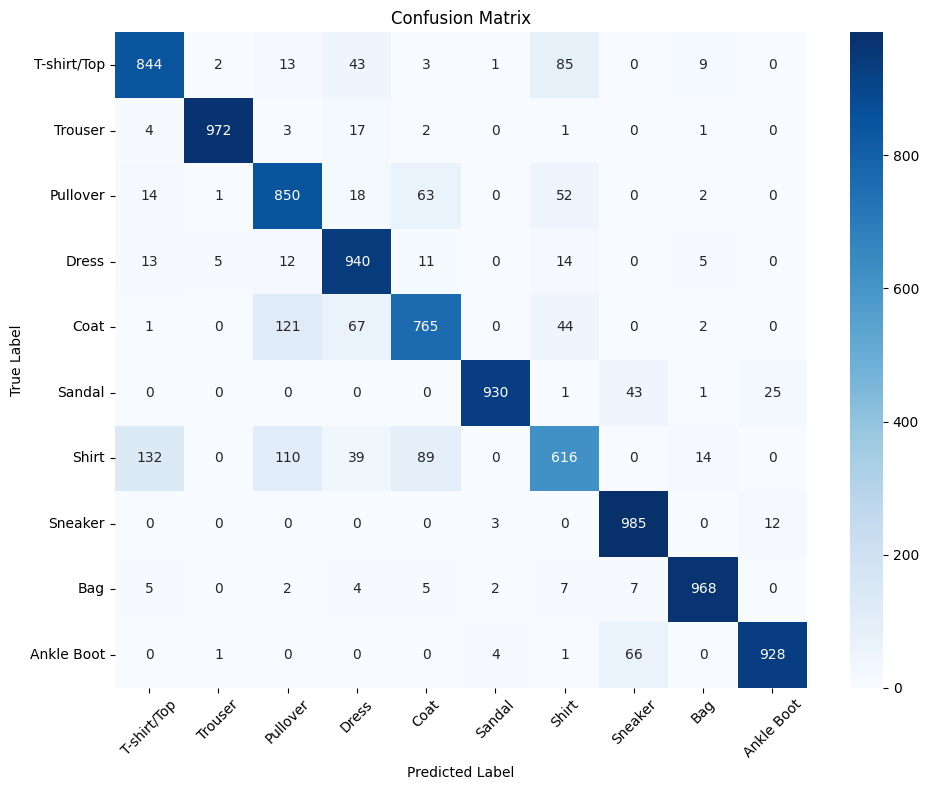

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()

save_plot("Confusion_Matrix")

plt.show()

Saved: /content/Experiment2_Figures/Accuracy_vs_Epoch.eps


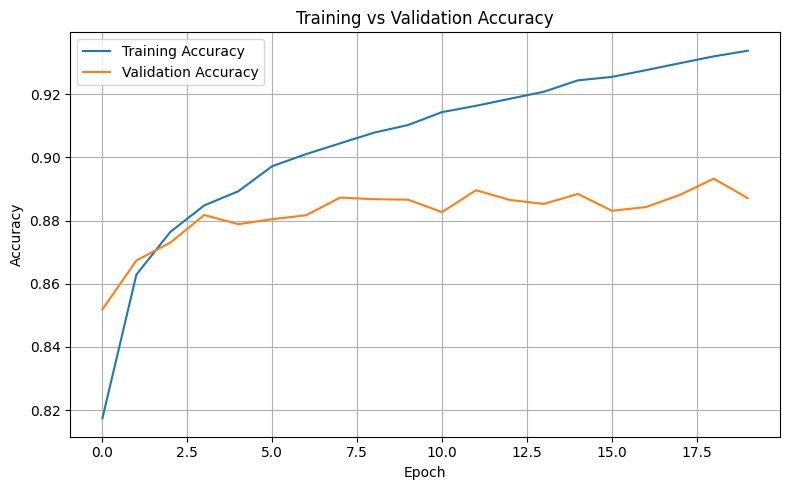

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.tight_layout()

save_plot("Accuracy_vs_Epoch")

plt.show()

Saved: /content/Experiment2_Figures/Loss_vs_Epoch.eps


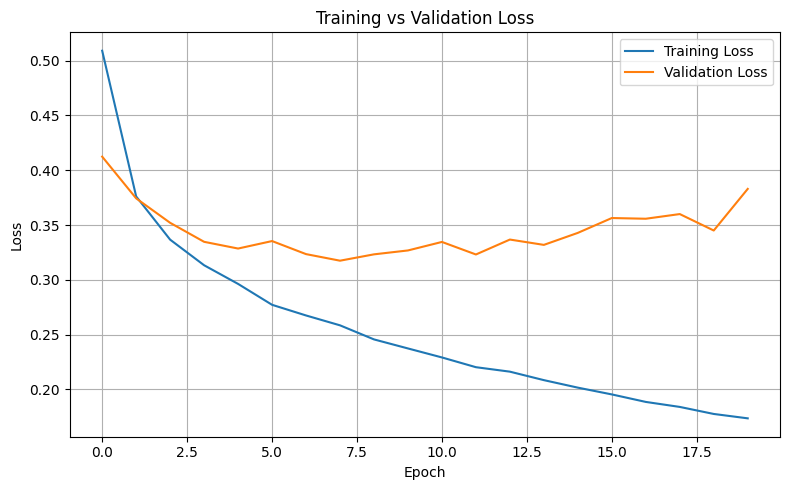

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.tight_layout()

save_plot("Loss_vs_Epoch")

plt.show()

Saved: /content/Experiment2_Figures/Hyperparameter_Search_Results.eps


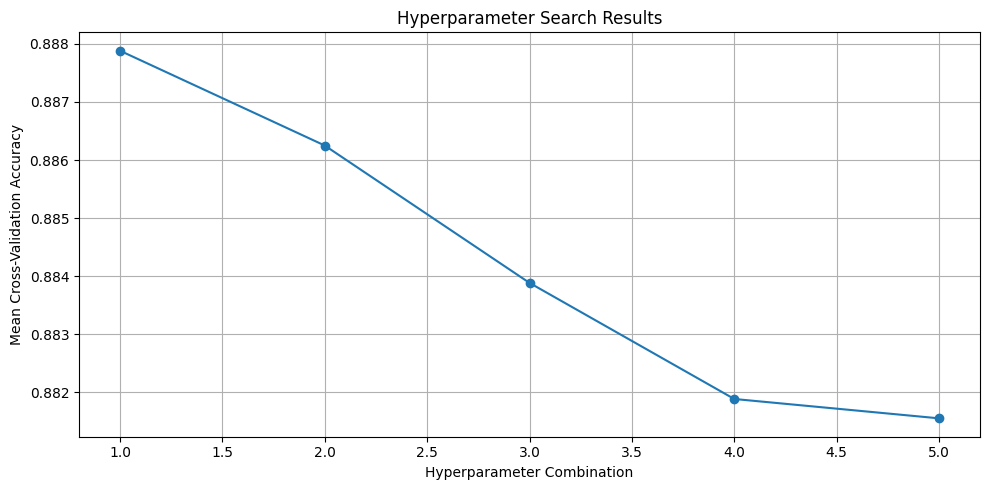

In [ ]:
import pandas as pd

results = pd.DataFrame(random_search.cv_results_)

results = results.sort_values("rank_test_score")

plt.figure(figsize=(10,5))

plt.plot(
    range(1, len(results)+1),
    results["mean_test_score"],
    marker="o"
)

plt.xlabel("Hyperparameter Combination")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.title("Hyperparameter Search Results")

plt.grid(True)

plt.tight_layout()

save_plot("Hyperparameter_Search_Results")

plt.show()

Saved: /content/Experiment2_Figures/Validation_Accuracy_vs_Epoch.eps


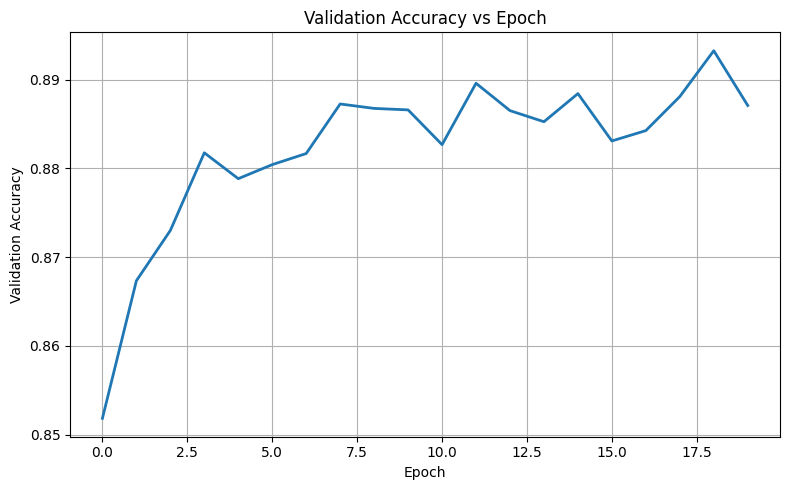

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['val_accuracy'], linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Epoch")

plt.grid(True)

plt.tight_layout()

save_plot("Validation_Accuracy_vs_Epoch")

plt.show()

Saved: /content/Experiment2_Figures/Validation_Loss_vs_Epoch.eps


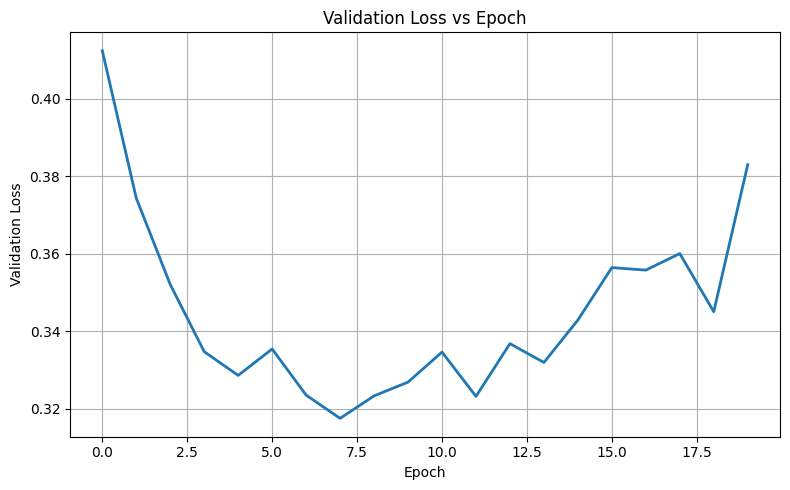

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['val_loss'], linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Epoch")

plt.grid(True)

plt.tight_layout()

save_plot("Validation_Loss_vs_Epoch")

plt.show()

In [ ]:
import shutil
from google.colab import files

# Zip the folder
shutil.make_archive(
    "/content/Experiment2_Figures",
    "zip",
    "/content/Experiment2_Figures"
)

# Download it
files.download("/content/Experiment2_Figures.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
best_hyperparameters_df = pd.DataFrame({
    "Hyperparameter": [
        "Hidden Layers",
        "Hidden Neurons",
        "Learning Rate",
        "Batch Size",
        "Optimizer",
        "Activation Function",
        "Epochs",
        "Dropout",
        "Cross-validation Accuracy",
        "Testing Accuracy"
    ],
    "Best Value": [
        2,
        "128, 64",
        0.001,          # Default learning rate of RMSprop
        64,
        "RMSprop",
        "ReLU",
        20,
        0.0,            # Not Used
        round(random_search.best_score_, 4),
        round(test_accuracy, 4)
    ]
})

best_hyperparameters_df

,Hyperparameter,Best Value
0,Hidden Layers,2
1,Hidden Neurons,"128, 64"
2,Learning Rate,0.001
3,Batch Size,64
4,Optimizer,RMSprop
5,Activation Function,ReLU
6,Epochs,20
7,Dropout,0.0
8,Cross-validation Accuracy,0.8879
9,Testing Accuracy,0.8903


In [ ]:
import time

start_time = time.time()

history = model.fit(
    X_train_flat,
    y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

baseline_training_time = time.time() - start_time

print(f"Baseline Training Time: {baseline_training_time:.2f} seconds")

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9360 - loss: 0.1703 - val_accuracy: 0.8924 - val_loss: 0.3640
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9376 - loss: 0.1651 - val_accuracy: 0.8907 - val_loss: 0.3788
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9390 - loss: 0.1614 - val_accuracy: 0.8915 - val_loss: 0.3625
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9419 - loss: 0.1543 - val_accuracy: 0.8869 - val_loss: 0.3920
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9407 - loss: 0.1561 - val_accuracy: 0.8867 - val_loss: 0.3973
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9435 - loss: 0.1490 - val_accuracy: 0.8884 - val_loss: 0.3952
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9450 - loss: 0.1455 - val_accuracy: 0.8897 - val_loss: 0.4130
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9460 - loss: 0.1410 - 

In [ ]:
import time

start_time = time.time()

best_model.fit(
    X_train_flat,
    y_train_cat
)

optimized_training_time = time.time() - start_time

print(f"Optimized Training Time: {optimized_training_time:.2f} seconds")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Optimized Training Time: 83.38 seconds


In [ ]:
performance_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "Training Time"
    ],
    "Baseline": [
        round(accuracy, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4),
        round(baseline_training_time, 2)
    ],
    "Optimized": [
        round(accuracy_opt, 4),
        round(precision_opt, 4),
        round(recall_opt, 4),
        round(f1_opt, 4),
        round(optimized_training_time, 2)
    ]
})

performance_df

,Metric,Baseline,Optimized
0,Accuracy,0.8798,0.8903
1,Precision,0.8800,0.8911
2,Recall,0.8798,0.8903
3,F1-Score,0.8783,0.8904
4,Training Time,153.1700,83.3800
